# Traditional CV EDA For Structure Stability Images

이 노트북은 `train/dev/test/generated_v2` 이미지를 전통적인 CV 관점에서 비교합니다.

핵심 목표
- 노이즈/렌더링 차이 검출: high-pass residual, Laplacian variance, FFT high-frequency ratio
- 명도/색조/채도 분포 추출: HSV 통계와 aggregated histogram
- 체커보드 기반 카메라 기하 분석: 선분, vanishing point, 촬영각 proxy
- 그림자 기반 조명/촬영각 보조 추정: shadow area, shadow axis angle
- 추가 EDA: blur/sharpness, 구조물 bbox, split 간 domain shift proxy

주의
- 사용자 설명대로 `train/test` 이미지는 `tools/simulator` 산출물과 설정이 다를 수 있습니다.
- 따라서 `generated_v2`는 정답 기준이라기보다 reference split으로만 사용합니다.
- 체커보드가 무한 패턴 형태라 일반적인 finite chessboard calibration이 항상 성공하지는 않습니다. 이 노트북은 calibration 시도 전에 robust proxy를 먼저 계산합니다.


In [2]:
# Setup: library import, path 설정, 기본 실행 옵션을 정의하는 셀
from __future__ import annotations

import json
import math
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data'
OUT_DIR = ROOT / 'outputs' / 'eda_cv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_SAMPLES_PER_SPLIT = 150  # None 으로 바꾸면 전체 샘플 처리
RANDOM_STATE = 42
RNG = np.random.default_rng(RANDOM_STATE)
SPLITS = ['train', 'dev', 'test', 'generated_v2']
LABEL_FILES = {
    'train': DATA_DIR / 'train.csv',
    'dev': DATA_DIR / 'dev.csv',
}

print({'root': str(ROOT), 'data_dir': str(DATA_DIR), 'out_dir': str(OUT_DIR), 'max_samples_per_split': MAX_SAMPLES_PER_SPLIT})

{'root': '/home/vsc/LLM_TUNE/structure-stability', 'data_dir': '/home/vsc/LLM_TUNE/structure-stability/data', 'out_dir': '/home/vsc/LLM_TUNE/structure-stability/outputs/eda_cv', 'max_samples_per_split': 150}


In [3]:
# Catalog: split별 샘플/이미지/라벨 메타데이터를 수집하는 셀
def load_label_map() -> dict[str, dict[str, str]]:
    label_map: dict[str, dict[str, str]] = {}
    for split, csv_path in LABEL_FILES.items():
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df.columns = [c.replace('\ufeff', '') for c in df.columns]
            label_map[split] = dict(zip(df['id'], df['label']))
    return label_map


def infer_generated_label(sample_dir: Path) -> str | None:
    meta_path = sample_dir / 'meta.json'
    if not meta_path.exists():
        return None
    try:
        meta = json.loads(meta_path.read_text())
    except json.JSONDecodeError:
        return None
    return meta.get('label') or meta.get('detected_label') or meta.get('mode_requested')


def build_catalog() -> tuple[pd.DataFrame, pd.DataFrame]:
    label_map = load_label_map()
    sample_rows = []
    image_rows = []

    for split in SPLITS:
        split_dir = DATA_DIR / split
        if not split_dir.exists():
            continue
        sample_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])
        for sample_dir in sample_dirs:
            sample_id = sample_dir.name
            label = label_map.get(split, {}).get(sample_id)
            if split == 'generated_v2' and label is None:
                label = infer_generated_label(sample_dir)

            front_path = sample_dir / 'front.png'
            top_path = sample_dir / 'top.png'
            video_path = sample_dir / 'simulation.mp4'
            meta_path = sample_dir / 'meta.json'

            sample_rows.append({
                'split': split,
                'sample_id': sample_id,
                'label': label,
                'front_exists': front_path.exists(),
                'top_exists': top_path.exists(),
                'video_exists': video_path.exists(),
                'meta_exists': meta_path.exists(),
                'sample_dir': sample_dir,
            })

            for view, path in [('front', front_path), ('top', top_path)]:
                if path.exists():
                    image_rows.append({
                        'split': split,
                        'sample_id': sample_id,
                        'label': label,
                        'view': view,
                        'image_path': path,
                    })

    sample_df = pd.DataFrame(sample_rows)
    image_df = pd.DataFrame(image_rows)
    return sample_df, image_df


sample_df, image_df = build_catalog()

print('sample_df shape:', sample_df.shape)
print('image_df shape:', image_df.shape)
display(sample_df.groupby('split')[['front_exists', 'top_exists', 'video_exists', 'meta_exists']].sum())
display(sample_df.groupby(['split', 'label']).size().rename('count').reset_index())


sample_df shape: (2100, 8)
image_df shape: (4200, 5)


,front_exists,top_exists,video_exists,meta_exists
split,,,,
dev,100,100,0,0
test,1000,1000,0,0
train,1000,1000,1000,0


,split,label,count
0,dev,stable,48
1,dev,unstable,52
2,train,stable,500
3,train,unstable,500


In [3]:
# Summary: split별 샘플 수와 라벨/메타 보유 현황을 요약하는 셀
summary = (
    sample_df.groupby('split')
    .agg(
        samples=('sample_id', 'count'),
        labeled=('label', lambda s: s.notna().sum()),
        videos=('video_exists', 'sum'),
        metas=('meta_exists', 'sum'),
    )
    .reset_index()
)

display(summary)

display(
    image_df.groupby(['split', 'view']).size().rename('images').reset_index()
)


,split,samples,labeled,videos,metas
0,dev,100,100,0,0
1,generated_v2,1,1,1,1
2,test,1000,0,0,0
3,train,1000,1000,1000,0


,split,view,images
0,dev,front,100
1,dev,top,100
2,generated_v2,front,1
3,generated_v2,top,1
4,test,front,1000
5,test,top,1000
6,train,front,1000
7,train,top,1000


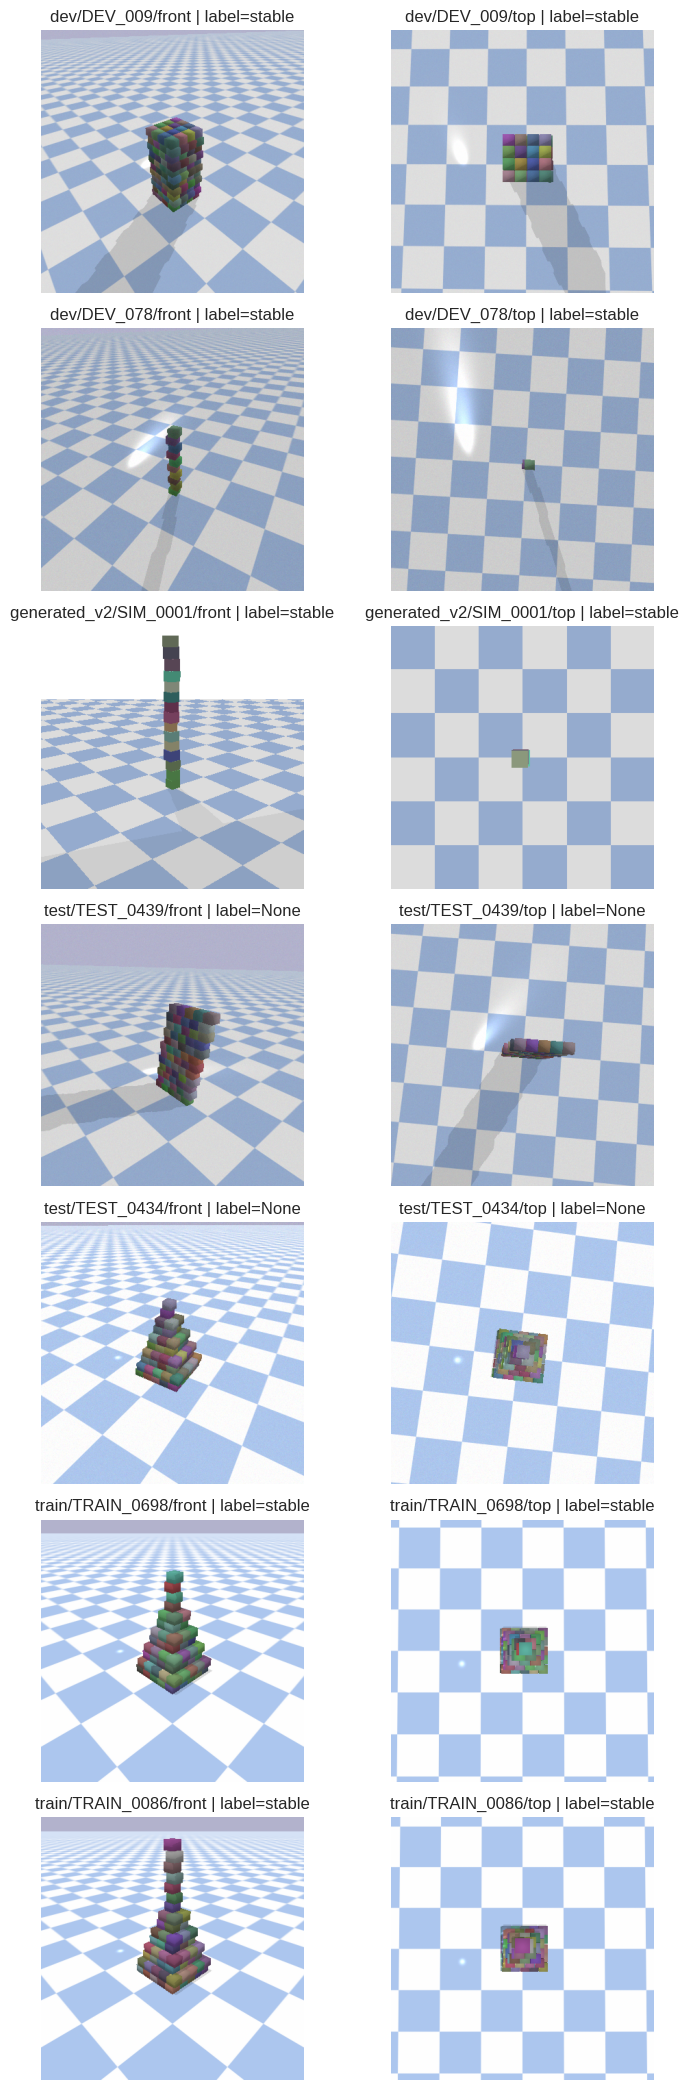

In [4]:
# Examples: split별 front/top 예시 이미지를 빠르게 확인하는 셀
def show_examples(df: pd.DataFrame, n_per_split: int = 3, seed: int = RANDOM_STATE) -> None:
    rng = np.random.default_rng(seed)
    rows = []
    for split, part in df.groupby('split'):
        sample_ids = part['sample_id'].drop_duplicates().to_numpy()
        if len(sample_ids) == 0:
            continue
        chosen = rng.choice(sample_ids, size=min(n_per_split, len(sample_ids)), replace=False)
        rows.extend([(split, sample_id) for sample_id in chosen])

    ncols = 2
    nrows = len(rows)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8, max(3 * nrows, 6)))
    if nrows == 1:
        axes = np.array([axes])

    for ax_row, (split, sample_id) in zip(axes, rows):
        for ax, view in zip(ax_row, ['front', 'top']):
            path = DATA_DIR / split / sample_id / f'{view}.png'
            img = np.asarray(Image.open(path).convert('RGB'))
            ax.imshow(img)
            label = sample_df.loc[sample_df['sample_id'].eq(sample_id) & sample_df['split'].eq(split), 'label']
            label_text = label.iloc[0] if len(label) else None
            ax.set_title(f'{split}/{sample_id}/{view} | label={label_text}')
            ax.axis('off')
    plt.tight_layout()


show_examples(image_df, n_per_split=2)


In [5]:
# Feature functions: CV feature extraction에 필요한 함수들을 정의하는 셀
def sample_image_rows(df: pd.DataFrame, max_samples_per_split: int | None = MAX_SAMPLES_PER_SPLIT) -> pd.DataFrame:
    if max_samples_per_split is None:
        return df.copy().reset_index(drop=True)

    keep_ids = []
    for split, part in df.groupby('split'):
        sample_ids = np.array(sorted(part['sample_id'].unique()))
        take = min(max_samples_per_split, len(sample_ids))
        chosen = RNG.choice(sample_ids, size=take, replace=False)
        keep_ids.extend((split, sample_id) for sample_id in chosen)

    keep_df = pd.DataFrame(keep_ids, columns=['split', 'sample_id'])
    sampled = df.merge(keep_df, on=['split', 'sample_id'], how='inner')
    return sampled.sort_values(['split', 'sample_id', 'view']).reset_index(drop=True)


def read_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def fft_high_freq_ratio(gray: np.ndarray, center_frac: float = 0.18) -> float:
    gray_f = gray.astype(np.float32)
    fft = np.fft.fftshift(np.fft.fft2(gray_f))
    mag = np.abs(fft)
    h, w = gray.shape
    cy, cx = h // 2, w // 2
    ry, rx = int(h * center_frac / 2), int(w * center_frac / 2)
    low_mask = np.zeros_like(gray_f, dtype=bool)
    low_mask[max(0, cy - ry): min(h, cy + ry + 1), max(0, cx - rx): min(w, cx + rx + 1)] = True
    total = mag.sum() + 1e-6
    high = mag[~low_mask].sum()
    return float(high / total)


def hue_entropy(hue: np.ndarray, sat: np.ndarray, bins: int = 36) -> float:
    valid = sat > 25
    if valid.sum() < 64:
        return np.nan
    hist, _ = np.histogram(hue[valid], bins=bins, range=(0, 180), density=True)
    hist = hist[hist > 0]
    return float(-(hist * np.log(hist + 1e-9)).sum())


def estimate_structure_mask(rgb: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    h, w = lab.shape[:2]
    border = np.concatenate([
        lab[:18].reshape(-1, 3),
        lab[-18:].reshape(-1, 3),
        lab[:, :18].reshape(-1, 3),
        lab[:, -18:].reshape(-1, 3),
    ], axis=0)
    center = np.median(border, axis=0)
    dist = np.linalg.norm(lab.astype(np.float32) - center.astype(np.float32), axis=2)
    thr = np.percentile(dist, 84)
    mask = (dist > thr).astype(np.uint8) * 255
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n_labels <= 1:
        return np.zeros((h, w), dtype=np.uint8)

    image_center = np.array([w / 2, h / 2])
    best_score = None
    best_idx = None
    for idx in range(1, n_labels):
        area = stats[idx, cv2.CC_STAT_AREA]
        if area < 80:
            continue
        x = stats[idx, cv2.CC_STAT_LEFT]
        y = stats[idx, cv2.CC_STAT_TOP]
        ww = stats[idx, cv2.CC_STAT_WIDTH]
        hh = stats[idx, cv2.CC_STAT_HEIGHT]
        centroid = np.array([x + ww / 2, y + hh / 2])
        center_penalty = np.linalg.norm((centroid - image_center) / np.array([w, h]))
        score = area - 4000 * center_penalty
        if best_score is None or score > best_score:
            best_score = score
            best_idx = idx

    out = np.zeros((h, w), dtype=np.uint8)
    if best_idx is not None:
        out[labels == best_idx] = 255
    return out


def detect_checker_lines(gray: np.ndarray, view: str) -> list[tuple[int, int, int, int, float, float]]:
    h, w = gray.shape
    if view == 'front':
        roi = gray[h // 4 :, :]
        y_offset = h // 4
    else:
        roi = gray
        y_offset = 0

    blur = cv2.GaussianBlur(roi, (5, 5), 0)
    edges = cv2.Canny(blur, 60, 140)
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=55,
        minLineLength=max(20, int(0.08 * w)),
        maxLineGap=8,
    )

    out = []
    if lines is None:
        return out

    for line in lines[:, 0, :]:
        x1, y1, x2, y2 = map(int, line)
        y1 += y_offset
        y2 += y_offset
        dx = x2 - x1
        dy = y2 - y1
        length = float(math.hypot(dx, dy))
        if length < max(20, 0.08 * w):
            continue
        angle = math.degrees(math.atan2(dy, dx))
        angle = ((angle + 90) % 180) - 90
        if view == 'front' and abs(angle) < 8:
            continue
        out.append((x1, y1, x2, y2, length, angle))

    out.sort(key=lambda x: x[4], reverse=True)
    return out[:40]


def line_to_abc(line: tuple[int, int, int, int, float, float]) -> np.ndarray:
    x1, y1, x2, y2, _, _ = line
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    norm = math.hypot(a, b) + 1e-6
    return np.array([a / norm, b / norm, c / norm], dtype=np.float32)


def intersections_from_lines(lines: list[tuple[int, int, int, int, float, float]], width: int, height: int) -> tuple[float, float, float, int]:
    if len(lines) < 2:
        return np.nan, np.nan, np.nan, 0

    points = []
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            if abs(lines[i][5] - lines[j][5]) < 12:
                continue
            l1 = line_to_abc(lines[i])
            l2 = line_to_abc(lines[j])
            x = np.cross(l1, l2)
            if abs(x[2]) < 1e-6:
                continue
            px = x[0] / x[2]
            py = x[1] / x[2]
            if -width <= px <= 2 * width and -height <= py <= 2 * height:
                points.append((px, py))

    if len(points) < 3:
        return np.nan, np.nan, np.nan, len(points)

    pts = np.array(points, dtype=np.float32)
    median = np.median(pts, axis=0)
    spread = np.median(np.linalg.norm(pts - median, axis=1)) / math.hypot(width, height)
    return float(median[0]), float(median[1]), float(spread), len(points)


def line_curvature_proxy(gray: np.ndarray, lines: list[tuple[int, int, int, int, float, float]], max_lines: int = 6) -> float:
    edges = cv2.Canny(gray, 60, 140)
    yy, xx = np.where(edges > 0)
    if len(xx) == 0 or len(lines) == 0:
        return np.nan

    residuals = []
    for line in lines[:max_lines]:
        x1, y1, x2, y2, _, _ = line
        xmin, xmax = sorted([x1, x2])
        ymin, ymax = sorted([y1, y2])
        pad = 4
        mask = (xx >= xmin - pad) & (xx <= xmax + pad) & (yy >= ymin - pad) & (yy <= ymax + pad)
        if mask.sum() < 25:
            continue
        pts = np.column_stack([xx[mask], yy[mask]]).astype(np.float32)
        p1 = np.array([x1, y1], dtype=np.float32)
        p2 = np.array([x2, y2], dtype=np.float32)
        v = p2 - p1
        denom = np.linalg.norm(v) + 1e-6
        dist = np.abs((pts[:, 0] - x1) * v[1] - (pts[:, 1] - y1) * v[0]) / denom
        residuals.append(np.median(dist))

    if not residuals:
        return np.nan
    return float(np.median(residuals))


def estimate_shadow_metrics(rgb: np.ndarray, structure_mask: np.ndarray, view: str) -> tuple[float, float, float]:
    if view != 'front':
        return np.nan, np.nan, np.nan

    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h, w = hsv.shape[:2]
    sat = hsv[:, :, 1]
    val = hsv[:, :, 2]
    roi_mask = np.zeros((h, w), dtype=np.uint8)
    roi_mask[h // 3 :, :] = 1

    dark_thr = np.percentile(val[roi_mask.astype(bool)], 28)
    shadow = ((sat < 70) & (val < dark_thr) & (roi_mask > 0)).astype(np.uint8)
    if structure_mask is not None:
        shadow[structure_mask > 0] = 0

    shadow = cv2.morphologyEx(shadow, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    shadow = cv2.morphologyEx(shadow, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(shadow, connectivity=8)
    best_idx = None
    best_area = 0
    for idx in range(1, n_labels):
        area = int(stats[idx, cv2.CC_STAT_AREA])
        y = int(stats[idx, cv2.CC_STAT_TOP])
        hh = int(stats[idx, cv2.CC_STAT_HEIGHT])
        if area < 120:
            continue
        if y + hh < h // 2:
            continue
        if area > best_area:
            best_area = area
            best_idx = idx

    if best_idx is None:
        return 0.0, np.nan, np.nan

    yy, xx = np.where(labels == best_idx)
    pts = np.column_stack([xx, yy]).astype(np.float32)
    centered = pts - pts.mean(axis=0, keepdims=True)
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major = eigvecs[:, np.argmax(eigvals)]
    angle = math.degrees(math.atan2(major[1], major[0]))
    elongation = float(np.sqrt(eigvals.max() / (eigvals.min() + 1e-6)))
    area_ratio = float(best_area / (h * w))
    return area_ratio, angle, elongation


def chessboard_detection(gray: np.ndarray, view: str) -> tuple[int, int, int]:
    if view != 'front':
        return 0, -1, -1
    flags = cv2.CALIB_CB_EXHAUSTIVE + cv2.CALIB_CB_ACCURACY
    for pattern in [(5, 5), (6, 6), (7, 7), (8, 8), (9, 9)]:
        ok, _ = cv2.findChessboardCornersSB(gray, pattern, flags=flags)
        if ok:
            return 1, pattern[0], pattern[1]
    return 0, -1, -1


def extract_image_features(row: dict | pd.Series) -> dict:
    row = dict(row)
    rgb = read_rgb(Path(row['image_path']))
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h, w = gray.shape

    structure_mask = estimate_structure_mask(rgb)
    structure_area = float((structure_mask > 0).mean())
    ys, xs = np.where(structure_mask > 0)
    if len(xs):
        bbox_w = (xs.max() - xs.min() + 1) / w
        bbox_h = (ys.max() - ys.min() + 1) / h
        center_x = xs.mean() / w
        center_y = ys.mean() / h
    else:
        bbox_w = bbox_h = center_x = center_y = np.nan

    lines = detect_checker_lines(gray, row['view'])
    vp_x, vp_y, vp_spread, n_intersections = intersections_from_lines(lines, w, h)
    curvature = line_curvature_proxy(gray, lines)
    shadow_area, shadow_angle, shadow_elongation = estimate_shadow_metrics(rgb, structure_mask, row['view'])
    board_found, board_nx, board_ny = chessboard_detection(gray, row['view'])

    gray_f = gray.astype(np.float32)
    blur_sigma = cv2.GaussianBlur(gray_f, (0, 0), 1.0)
    residual = gray_f - blur_sigma

    sat = hsv[:, :, 1]
    val = hsv[:, :, 2]
    hue = hsv[:, :, 0]

    feature_row = {
        'split': row['split'],
        'sample_id': row['sample_id'],
        'label': row['label'],
        'view': row['view'],
        'image_path': str(row['image_path']),
        'width': w,
        'height': h,
        'mean_r': float(rgb[:, :, 0].mean()),
        'mean_g': float(rgb[:, :, 1].mean()),
        'mean_b': float(rgb[:, :, 2].mean()),
        'std_r': float(rgb[:, :, 0].std()),
        'std_g': float(rgb[:, :, 1].std()),
        'std_b': float(rgb[:, :, 2].std()),
        'brightness_mean': float(val.mean() / 255.0),
        'brightness_std': float(val.std() / 255.0),
        'saturation_mean': float(sat.mean() / 255.0),
        'saturation_std': float(sat.std() / 255.0),
        'hue_entropy': hue_entropy(hue, sat),
        'laplacian_var': float(cv2.Laplacian(gray_f, cv2.CV_32F).var()),
        'noise_residual_std': float(residual.std()),
        'fft_high_freq_ratio': fft_high_freq_ratio(gray),
        'edge_density': float((cv2.Canny(gray, 60, 140) > 0).mean()),
        'structure_area_ratio': structure_area,
        'structure_bbox_w': float(bbox_w),
        'structure_bbox_h': float(bbox_h),
        'structure_center_x': float(center_x),
        'structure_center_y': float(center_y),
        'checker_line_count': int(len(lines)),
        'vp_x': vp_x,
        'vp_y': vp_y,
        'vp_spread': vp_spread,
        'vp_pitch_proxy': float(vp_y / h) if not np.isnan(vp_y) else np.nan,
        'vp_intersections': int(n_intersections),
        'distortion_proxy': float(curvature / math.hypot(w, h)) if not np.isnan(curvature) else np.nan,
        'shadow_area_ratio': shadow_area,
        'shadow_angle_deg': shadow_angle,
        'shadow_elongation': shadow_elongation,
        'chessboard_found': int(board_found),
        'chessboard_nx': int(board_nx),
        'chessboard_ny': int(board_ny),
    }
    return feature_row


In [6]:
# Feature extraction: 샘플링된 이미지에서 CV feature를 실제로 추출하고 저장하는 셀
sampled_images = sample_image_rows(image_df, MAX_SAMPLES_PER_SPLIT)
print('sampled rows:', sampled_images.shape)
display(sampled_images.groupby(['split', 'view']).size().rename('rows').reset_index())

feature_rows = []
for row in tqdm(list(sampled_images.itertuples(index=False)), desc='Extracting CV features'):
    feature_rows.append(extract_image_features(row._asdict()))

feat_df = pd.DataFrame(feature_rows)
feat_path = OUT_DIR / f'cv_features_max{MAX_SAMPLES_PER_SPLIT or "all"}.csv'
feat_df.to_csv(feat_path, index=False)
print('saved:', feat_path)
feat_df.head()


sampled rows: (802, 5)


,split,view,rows
0,dev,front,100
1,dev,top,100
2,generated_v2,front,1
3,generated_v2,top,1
4,test,front,150
5,test,top,150
6,train,front,150
7,train,top,150


Extracting CV features:   0%|          | 0/802 [00:00<?, ?it/s]

saved: /media/hdd0/whyz/structure-stability/outputs/eda_cv/cv_features_max150.csv


,split,sample_id,label,view,image_path,width,height,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness_mean,brightness_std,saturation_mean,saturation_std,hue_entropy,laplacian_var,noise_residual_std,fft_high_freq_ratio,edge_density,structure_area_ratio,structure_bbox_w,structure_bbox_h,structure_center_x,structure_center_y,checker_line_count,vp_x,vp_y,vp_spread,vp_pitch_proxy,vp_intersections,distortion_proxy,shadow_area_ratio,shadow_angle_deg,shadow_elongation,chessboard_found,chessboard_nx,chessboard_ny
0,dev,DEV_001,unstable,front,/media/hdd0/whyz/structure-stability/data/dev/...,384,384,172.413947,181.888041,198.582933,31.124773,24.013015,16.754927,0.782911,0.060537,0.146496,0.114977,0.588366,327.098755,5.063201,0.637002,0.093370,0.016703,0.075521,0.309896,0.522397,0.490718,40,129.527893,151.791138,0.211187,0.395289,469,0.049573,0.006321,-177.93349,6.702360,0,-1,-1
1,dev,DEV_001,unstable,top,/media/hdd0/whyz/structure-stability/data/dev/...,384,384,173.836711,184.492628,200.560167,33.869543,24.665439,13.570049,0.790835,0.053379,0.147785,0.126140,0.474643,175.189026,3.547049,0.615081,0.038378,0.038384,0.252604,0.351562,0.124718,0.767877,29,179.659241,191.445312,0.285986,0.498556,234,0.000904,NaN,NaN,NaN,0,-1,-1
2,dev,DEV_002,unstable,front,/media/hdd0/whyz/structure-stability/data/dev/...,384,384,185.392524,193.651903,211.024957,42.192023,40.175989,40.430586,0.839384,0.131573,0.158675,0.129245,0.693831,571.769470,6.336119,0.653054,0.091180,0.109470,0.445312,0.606771,0.570366,0.492667,40,215.852448,154.639297,0.214350,0.402707,474,0.055829,0.000000,NaN,NaN,0,-1,-1
3,dev,DEV_002,unstable,top,/media/hdd0/whyz/structure-stability/data/dev/...,384,384,188.301866,198.890035,215.597670,45.336581,39.784610,37.405386,0.855615,0.124414,0.158462,0.142711,0.575652,283.186249,4.830537,0.591829,0.050693,0.099331,0.242188,0.578125,0.507517,0.268794,37,128.554352,196.761444,0.276229,0.512400,349,0.000786,NaN,NaN,NaN,0,-1,-1
4,dev,DEV_003,unstable,front,/media/hdd0/whyz/structure-stability/data/dev/...,384,384,192.676439,204.514086,223.686727,44.590903,40.118734,37.805067,0.883043,0.134958,0.161107,0.127423,0.567246,544.732727,6.453748,0.627385,0.103509,0.067593,0.289062,0.510417,0.515990,0.464815,40,195.186813,133.444656,0.303273,0.347512,567,0.060775,0.010695,123.78102,3.503442,0,-1,-1


In [7]:
# Feature summary: split/view 기준 핵심 feature 통계를 요약하는 셀
metric_cols = [
    'brightness_mean', 'saturation_mean', 'hue_entropy',
    'laplacian_var', 'noise_residual_std', 'fft_high_freq_ratio', 'edge_density',
    'structure_area_ratio', 'structure_bbox_h', 'structure_bbox_w',
    'checker_line_count', 'vp_pitch_proxy', 'vp_spread', 'distortion_proxy',
    'shadow_area_ratio', 'shadow_angle_deg', 'shadow_elongation',
]

summary_stats = (
    feat_df.groupby(['split', 'view'])[metric_cols]
    .agg(['mean', 'std', 'median'])
    .round(4)
)
summary_stats


brightness_mean                 saturation_mean                 hue_entropy                 laplacian_var                     \
                              mean     std  median            mean     std  median        mean     std  median          mean      std    median   
split        view                                                                                                                                 
dev          front          0.8274  0.0476  0.8176          0.1552  0.0070  0.1559      0.6272  0.0676  0.6507      466.1731  99.8849  462.7603   
             top            0.8468  0.0503  0.8435          0.1522  0.0049  0.1516      0.5088  0.0555  0.5111      238.4122  56.4460  233.9555   
generated_v2 front          0.8534     NaN  0.8534          0.1072     NaN  0.1072      0.4242     NaN  0.4242      743.6733      NaN  743.6733   
             top            0.8341     NaN  0.8341          0.1396     NaN  0.1396      0.3340     NaN  0.3340      151.3038      NaN  151.3038   
test         front          0.8256  0.0437  0.8207          0.1540  0.0079  0.1549      0.6167  0.0717  0.6276      444.1356  91.0518  435.6351   
             top            0.8464  0.0484  0.8393          0.1504  0.0045  0.1499      0.4890  0.0543  0.4919      220.2096  53.4151  217.0915   
train        front          0.9254  0.0143  0.9214          0.1476  0.0076  0.1477      0.4957  0.0481  0.5050      537.5971  73.0127  552.3420   
             top            0.9546  0.0090  0.9574          0.1434  0.0042  0.1419      0.3761  0.0461  0.3589      191.0662  51.2317  182.6999   

                   noise_residual_std                 fft_high_freq_ratio                 edge_density                 structure_area_ratio                  \
                                 mean     std  median                mean     std  median         mean     std  median                 mean     std  median   
split        view                                                                                                                                             
dev          front             5.7904  0.5380  5.7499              0.6394  0.0110  0.6398       0.0964  0.0129  0.0965               0.0666  0.0346  0.0674   
             top               4.1431  0.4055  4.1504              0.6136  0.0176  0.6140       0.0412  0.0031  0.0405               0.0420  0.0310  0.0363   
generated_v2 front             6.9362     NaN  6.9362              0.6824     NaN  0.6824       0.0597     NaN  0.0597               0.1000     NaN  0.1000   
             top               3.7189     NaN  3.7189              0.5691     NaN  0.5691       0.0260     NaN  0.0260               0.0049     NaN  0.0049   
test         front             5.6981  0.4990  5.6845              0.6369  0.0114  0.6361       0.0949  0.0118  0.0950               0.0644  0.0355  0.0649   
             top               4.0186  0.3682  3.9851              0.6095  0.0208  0.6118       0.0405  0.0026  0.0405               0.0345  0.0257  0.0324   
train        front             6.5089  0.2979  6.5445              0.6190  0.0067  0.6200       0.1048  0.0048  0.1048               0.0554  0.0277  0.0632   
             top               4.2664  0.4234  4.2249              0.5331  0.0223  0.5304       0.0398  0.0032  0.0388               0.0244  0.0212  0.0172   

                   structure_bbox_h                 structure_bbox_w                 checker_line_count                vp_pitch_proxy                  \
                               mean     std  median             mean     std  median               mean     std median           mean     std  median   
split        view                                                                                                                                       
dev          front           0.4580  0.1199  0.4479           0.2970  0.1729  0.2773            38.2100  2.8044   40.0         0.3886  0.0353  0.3811   
             top             0.2675  0.

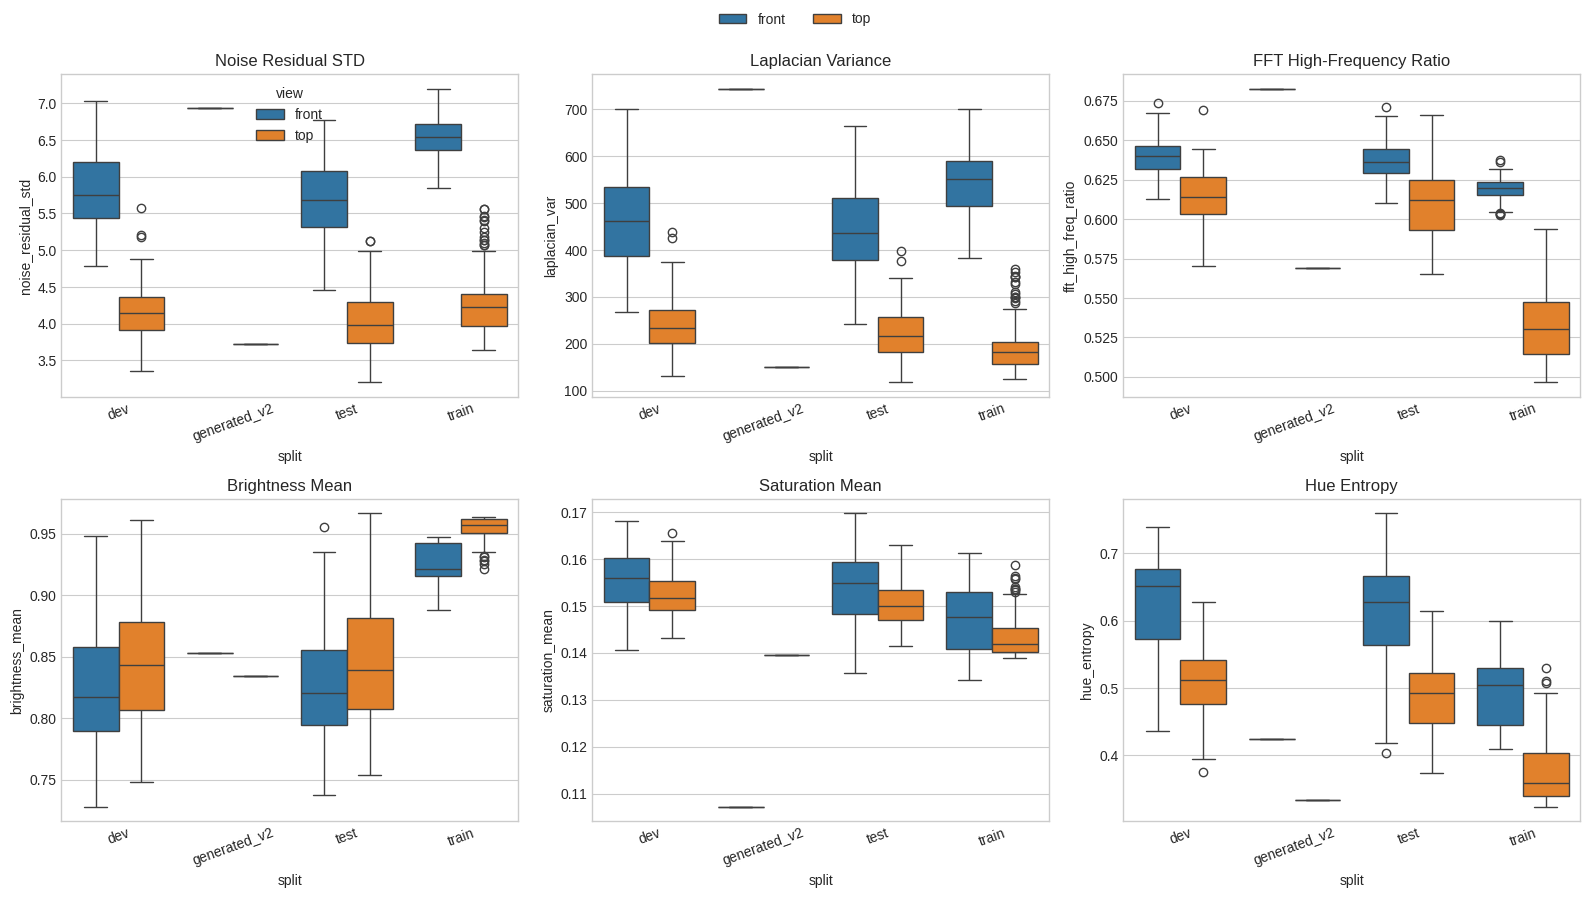

In [8]:
# Plot: 노이즈/색/주파수 계열 feature를 boxplot으로 비교하는 셀
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ('noise_residual_std', 'Noise Residual STD'),
    ('laplacian_var', 'Laplacian Variance'),
    ('fft_high_freq_ratio', 'FFT High-Frequency Ratio'),
    ('brightness_mean', 'Brightness Mean'),
    ('saturation_mean', 'Saturation Mean'),
    ('hue_entropy', 'Hue Entropy'),
]

for idx, (ax, (col, title)) in enumerate(zip(axes.flat, plot_specs)):
    sns.boxplot(data=feat_df, x='split', y=col, hue='view', ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    if idx > 0:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
plt.tight_layout(rect=(0, 0, 1, 0.96))


In [9]:
# Histogram functions: HSV 픽셀 분포를 split/view 단위로 누적하는 셀
def aggregate_hsv_hist(df: pd.DataFrame, bins: int = 32) -> pd.DataFrame:
    rows = []
    for (split, view), part in tqdm(df.groupby(['split', 'view']), desc='HSV histogram'):
        hue_hist = np.zeros(bins, dtype=np.float64)
        sat_hist = np.zeros(bins, dtype=np.float64)
        val_hist = np.zeros(bins, dtype=np.float64)
        n_images = 0

        for image_path in part['image_path']:
            rgb = read_rgb(Path(image_path))
            hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
            hue = hsv[:, :, 0]
            sat = hsv[:, :, 1]
            val = hsv[:, :, 2]

            h_hist, _ = np.histogram(hue, bins=bins, range=(0, 180), density=False)
            s_hist, _ = np.histogram(sat, bins=bins, range=(0, 256), density=False)
            v_hist, _ = np.histogram(val, bins=bins, range=(0, 256), density=False)
            hue_hist += h_hist
            sat_hist += s_hist
            val_hist += v_hist
            n_images += 1

        for idx in range(bins):
            rows.append({'split': split, 'view': view, 'channel': 'hue', 'bin': idx, 'value': hue_hist[idx], 'n_images': n_images})
            rows.append({'split': split, 'view': view, 'channel': 'sat', 'bin': idx, 'value': sat_hist[idx], 'n_images': n_images})
            rows.append({'split': split, 'view': view, 'channel': 'val', 'bin': idx, 'value': val_hist[idx], 'n_images': n_images})

    hist_df = pd.DataFrame(rows)
    hist_df['density'] = hist_df.groupby(['split', 'view', 'channel'])['value'].transform(lambda s: s / (s.sum() + 1e-9))
    return hist_df


hist_df = aggregate_hsv_hist(sampled_images)
hist_df.head()


HSV histogram:   0%|          | 0/8 [00:00<?, ?it/s]

,split,view,channel,bin,value,n_images,density
0,dev,front,hue,0,486735.0,100,0.033009
1,dev,front,sat,0,4231024.0,100,0.286935
2,dev,front,val,0,0.0,100,0.000000
3,dev,front,hue,1,169237.0,100,0.011477
4,dev,front,sat,1,1321422.0,100,0.089615


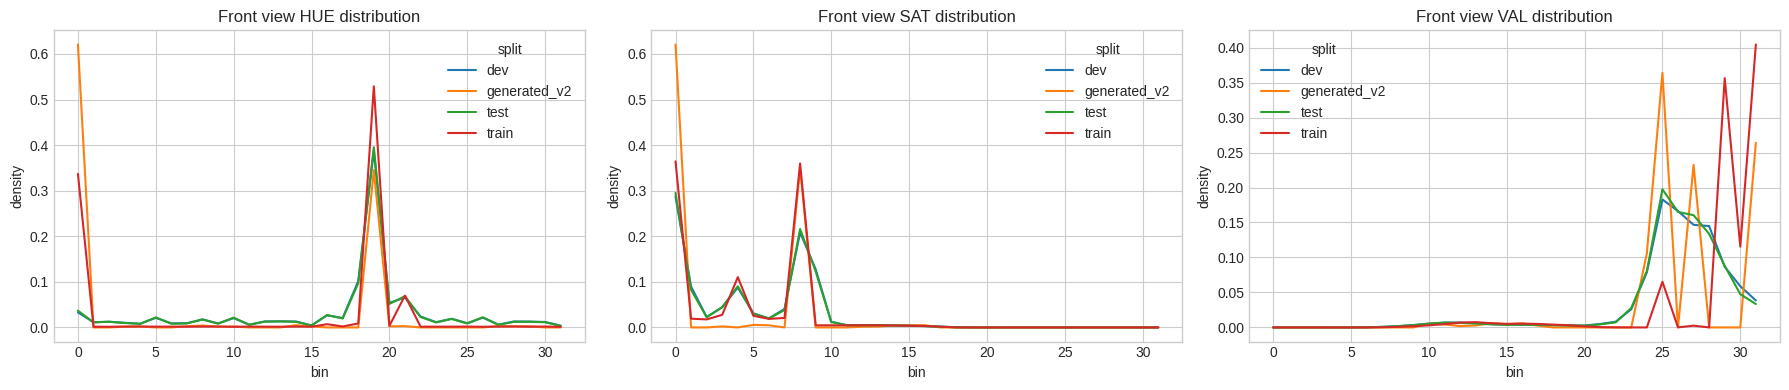

In [10]:
# Plot: front view 기준 HSV 분포 곡선을 비교하는 셀
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, channel in zip(axes, ['hue', 'sat', 'val']):
    sns.lineplot(
        data=hist_df.query('channel == @channel and view == "front"'),
        x='bin', y='density', hue='split', ax=ax
    )
    ax.set_title(f'Front view {channel.upper()} distribution')
plt.tight_layout()


checker_line_count                vp_pitch_proxy                 vp_spread                 distortion_proxy                 chessboard_found  \
                           mean median     std           mean  median     std      mean  median     std             mean  median     std             mean   
split                                                                                                                                                       
dev                     38.2100   40.0  2.8044         0.3886  0.3811  0.0353    0.2842  0.2857  0.0347           0.0647  0.0624  0.0162           0.3500   
generated_v2            40.0000   40.0     NaN         0.4557  0.4557     NaN    0.2626  0.2626     NaN           0.0651  0.0651     NaN           0.0000   
test                    38.2600   40.0  2.6708         0.3896  0.3800  0.0370    0.2832  0.2828  0.0330           0.0637  0.0624  0.0172           0.1800   
train                   39.6267   40.0  1.0590         0.3525  0.3538  0.0158    0.3113  0.3080  0.0299           0.0836  0.0842  0.0227           0.2733   

                            shadow_area_ratio                 shadow_elongation                  
             median     std              mean  median     std              mean  median     std  
split                                                                                            
dev             0.0  0.4794            0.0127  0.0085  0.0125            3.3765  2.8361  2.1716  
generated_v2    0.0     NaN            0.0000  0.0000     NaN               NaN     NaN     NaN  
test            0.0  0.3855            0.0136  0.0095  0.0129            3.7348  3.1853  2.6134  
train           0.0  0.4472            0.0023  0.0015  0.0036            2.1430  1.7828  1.0295

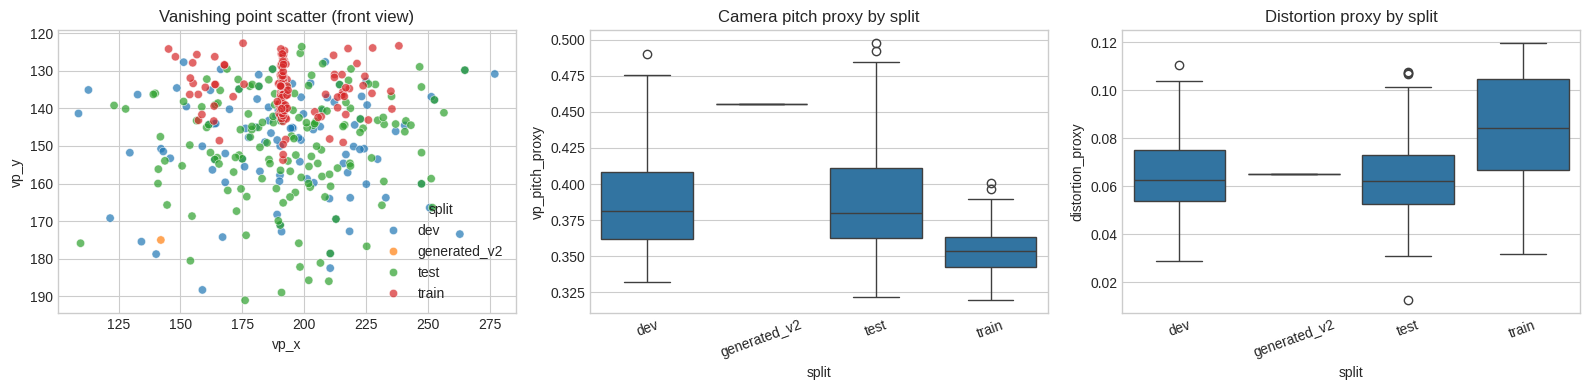

In [11]:
# Geometry summary: 체커보드/vanishing point/왜곡 proxy를 요약하고 시각화하는 셀
front_geom = feat_df.query('view == "front"').copy()

display(
    front_geom.groupby('split')[['checker_line_count', 'vp_pitch_proxy', 'vp_spread', 'distortion_proxy', 'chessboard_found', 'shadow_area_ratio', 'shadow_elongation']]
    .agg(['mean', 'median', 'std'])
    .round(4)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=front_geom, x='vp_x', y='vp_y', hue='split', alpha=0.7, ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title('Vanishing point scatter (front view)')

sns.boxplot(data=front_geom, x='split', y='vp_pitch_proxy', ax=axes[1])
axes[1].set_title('Camera pitch proxy by split')
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=front_geom, x='split', y='distortion_proxy', ax=axes[2])
axes[2].set_title('Distortion proxy by split')
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout()


noise_residual_std  brightness_mean  vp_pitch_proxy  shadow_area_ratio  structure_bbox_h
split        label                                                                                             
dev          stable                5.7865           0.8174          0.3877             0.0160            0.4848
             unstable              5.7940           0.8366          0.3894             0.0096            0.4332
generated_v2 stable                6.9362           0.8534          0.4557             0.0000            0.2578
train        stable                6.5301           0.9246          0.3524             0.0015            0.4272
             unstable              6.4904           0.9262          0.3527             0.0029            0.4168

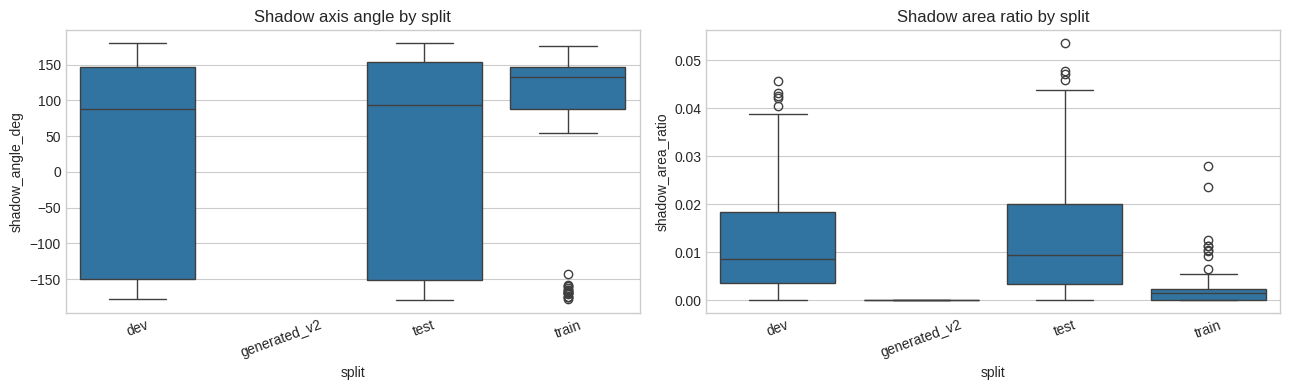

In [12]:
# Shadow summary: 그림자 기반 지표와 라벨별 평균 차이를 보는 셀
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=front_geom, x='split', y='shadow_angle_deg', ax=axes[0])
axes[0].set_title('Shadow axis angle by split')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=front_geom, x='split', y='shadow_area_ratio', ax=axes[1])
axes[1].set_title('Shadow area ratio by split')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()

if front_geom['label'].notna().any():
    display(
        front_geom[front_geom['label'].notna()]
        .groupby(['split', 'label'])[['noise_residual_std', 'brightness_mean', 'vp_pitch_proxy', 'shadow_area_ratio', 'structure_bbox_h']]
        .mean()
        .round(4)
    )


## Domain Shift Classification

전통적 CV feature만으로 split을 얼마나 잘 구분할 수 있는지 sample 단위 ROC-AUC로 확인합니다.

설계
- `front`와 `top` feature를 한 sample row로 합칩니다.
- front-top 차이(`delta_*`)도 추가합니다.
- `train vs test`, `train vs dev`, `dev vs test`에 대해 Logistic Regression과 RandomForest를 비교합니다.


In [13]:
# Domain classification functions: sample-level feature 결합과 ROC-AUC 평가 함수를 정의하는 셀
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def build_sample_level_features(feat_df: pd.DataFrame) -> pd.DataFrame:
    meta_cols = ['split', 'sample_id', 'label']
    value_cols = [c for c in feat_df.columns if c not in meta_cols + ['view', 'image_path']]

    wide_parts = []
    for view in sorted(feat_df['view'].unique()):
        part = feat_df.loc[feat_df['view'] == view, meta_cols + value_cols].copy()
        part = part.rename(columns={col: f'{view}_{col}' for col in value_cols})
        wide_parts.append(part)

    sample_level = wide_parts[0]
    for part in wide_parts[1:]:
        sample_level = sample_level.merge(part, on=meta_cols, how='outer')

    common_value_cols = [
        col for col in value_cols
        if f'front_{col}' in sample_level.columns and f'top_{col}' in sample_level.columns
    ]
    for col in common_value_cols:
        sample_level[f'delta_{col}'] = sample_level[f'front_{col}'] - sample_level[f'top_{col}']

    return sample_level


def make_domain_models(feature_cols: list[str]) -> dict[str, Pipeline]:
    num_prep = ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline(
                    steps=[
                        ('imputer', SimpleImputer(strategy='median')),
                        ('scaler', StandardScaler()),
                    ]
                ),
                feature_cols,
            )
        ]
    )

    return {
        'logreg': Pipeline(
            steps=[
                ('prep', num_prep),
                ('clf', LogisticRegression(max_iter=2000, random_state=42)),
            ]
        ),
        'rf': Pipeline(
            steps=[
                ('prep', ColumnTransformer([('num', SimpleImputer(strategy='median'), feature_cols)])),
                ('clf', RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
            ]
        ),
    }


def evaluate_domain_task(sample_level: pd.DataFrame, neg_split: str, pos_split: str, n_splits: int = 5) -> tuple[list[dict], list[dict]]:
    task_df = sample_level.loc[sample_level['split'].isin([neg_split, pos_split])].copy()
    task_df['target'] = (task_df['split'] == pos_split).astype(int)
    feature_cols = [c for c in task_df.columns if c not in ['split', 'sample_id', 'label', 'target']]
    feature_cols = [c for c in feature_cols if task_df[c].notna().any()]

    X = task_df[feature_cols]
    y = task_df['target'].to_numpy()
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    auc_rows = []
    importance_rows = []
    for model_name, model in make_domain_models(feature_cols).items():
        fold_aucs = []
        oof_pred = np.zeros(len(task_df), dtype=float)

        for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
            model.fit(X.iloc[train_idx], y[train_idx])
            pred = model.predict_proba(X.iloc[valid_idx])[:, 1]
            fold_auc = roc_auc_score(y[valid_idx], pred)
            oof_pred[valid_idx] = pred
            fold_aucs.append(fold_auc)
            auc_rows.append({
                'task': f'{neg_split}_vs_{pos_split}',
                'model': model_name,
                'fold': fold_idx,
                'auc': float(fold_auc),
            })

        model.fit(X, y)
        if model_name == 'logreg':
            raw_importance = np.abs(model.named_steps['clf'].coef_[0])
        else:
            raw_importance = model.named_steps['clf'].feature_importances_

        top_imp = (
            pd.Series(raw_importance, index=feature_cols)
            .sort_values(ascending=False)
            .head(12)
        )
        for feature, importance in top_imp.items():
            importance_rows.append({
                'task': f'{neg_split}_vs_{pos_split}',
                'model': model_name,
                'feature': feature,
                'importance': float(importance),
            })

        auc_rows.append({
            'task': f'{neg_split}_vs_{pos_split}',
            'model': model_name,
            'fold': 'oof',
            'auc': float(roc_auc_score(y, oof_pred)),
        })

    return auc_rows, importance_rows


In [14]:
# Domain classification run: sample-level feature를 만들고 split pair별 ROC-AUC를 계산하는 셀
sample_level_df = build_sample_level_features(feat_df.loc[feat_df['split'] != 'generated_v2'].copy())
task_pairs = [('dev', 'test'), ('train', 'dev'), ('train', 'test')]

auc_rows = []
importance_rows = []
for neg_split, pos_split in task_pairs:
    task_auc_rows, task_imp_rows = evaluate_domain_task(sample_level_df, neg_split, pos_split)
    auc_rows.extend(task_auc_rows)
    importance_rows.extend(task_imp_rows)

auc_df = pd.DataFrame(auc_rows)
importance_df = pd.DataFrame(importance_rows)

display(
    auc_df[auc_df['fold'].eq('oof')]
    .pivot(index='task', columns='model', values='auc')
    .round(4)
)

display(
    importance_df.sort_values(['task', 'model', 'importance'], ascending=[True, True, False])
    .groupby(['task', 'model'])
    .head(8)
)


model,logreg,rf
task,,
dev_vs_test,0.5228,0.3696
train_vs_dev,1.0000,0.9996
train_vs_test,1.0000,0.9998


,task,model,feature,importance
0,dev_vs_test,logreg,delta_mean_b,0.637101
1,dev_vs_test,logreg,front_structure_center_x,0.636804
2,dev_vs_test,logreg,delta_noise_residual_std,0.605631
3,dev_vs_test,logreg,delta_brightness_std,0.576546
4,dev_vs_test,logreg,delta_laplacian_var,0.572228
5,dev_vs_test,logreg,top_hue_entropy,0.534824
6,dev_vs_test,logreg,top_distortion_proxy,0.534046
7,dev_vs_test,logreg,delta_std_g,0.528009
12,dev_vs_test,rf,front_structure_center_x,0.025627
13,dev_vs_test,rf,delta_structure_center_x,0.023849


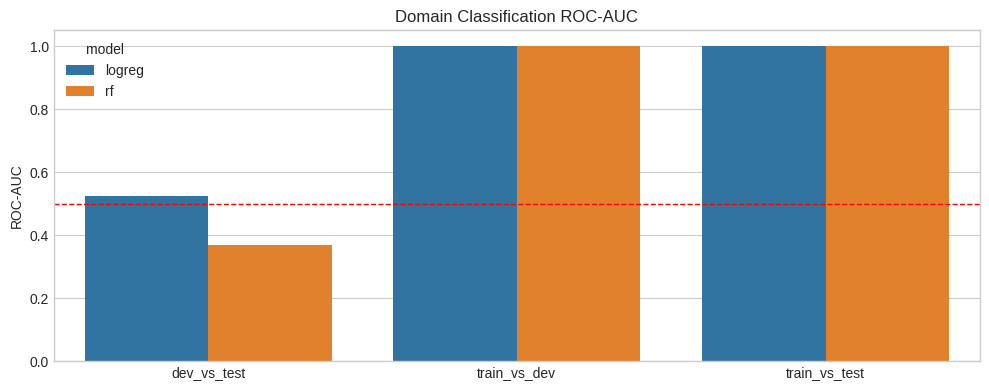

In [15]:
# Plot: domain classification ROC-AUC를 task/model별 barplot으로 시각화하는 셀
auc_plot_df = auc_df[auc_df['fold'].eq('oof')].copy()

plt.figure(figsize=(10, 4))
sns.barplot(data=auc_plot_df, x='task', y='auc', hue='model')
plt.ylim(0.0, 1.05)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1)
plt.title('Domain Classification ROC-AUC')
plt.ylabel('ROC-AUC')
plt.xlabel('')
plt.tight_layout()


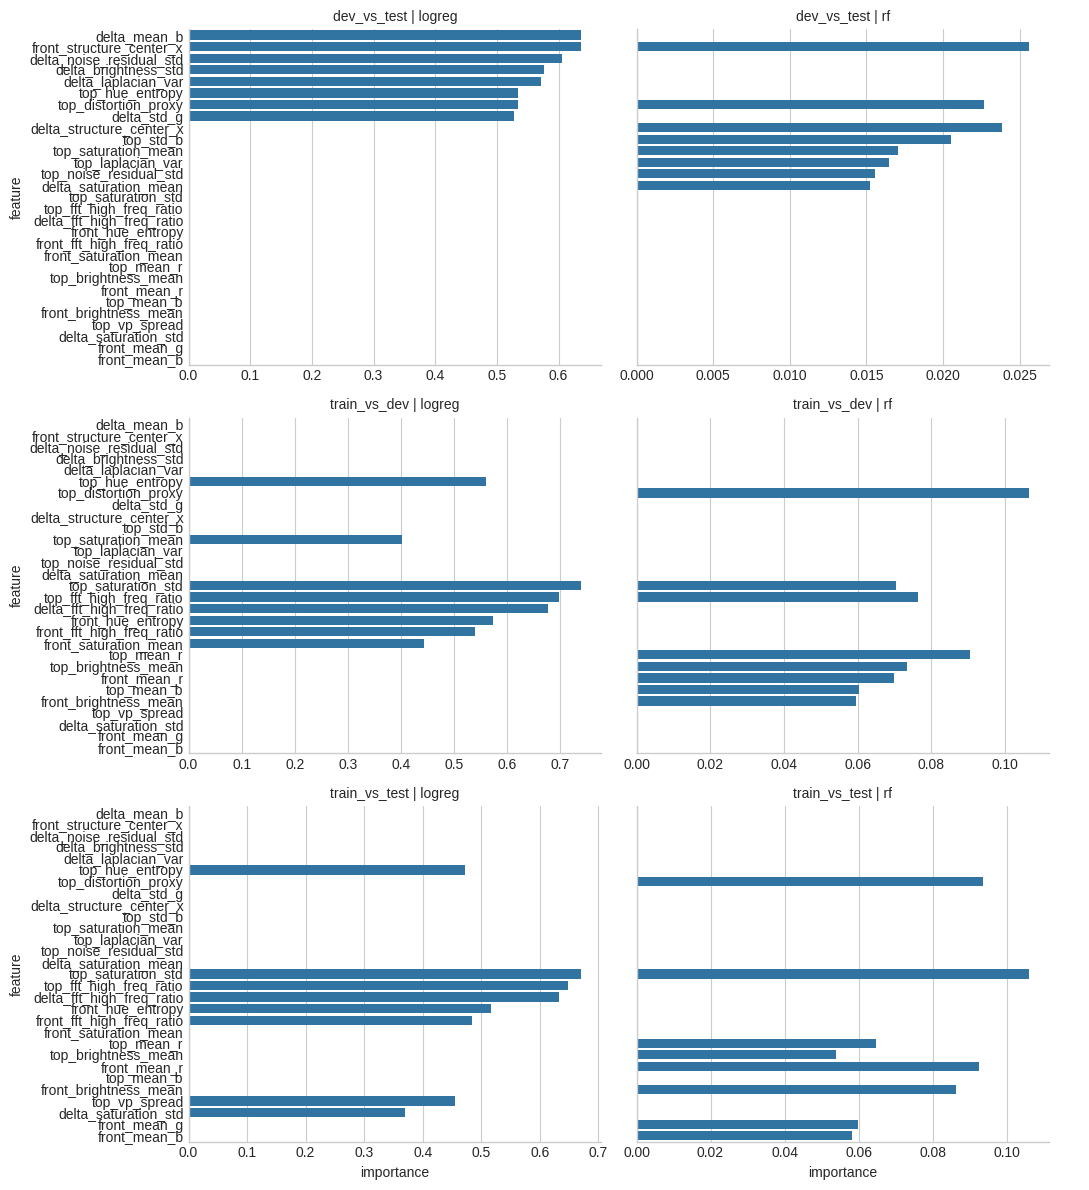

In [16]:
# Plot: domain classification에서 중요한 feature를 task/model별로 보는 셀
top_imp_plot_df = (
    importance_df.sort_values(['task', 'model', 'importance'], ascending=[True, True, False])
    .groupby(['task', 'model'])
    .head(8)
    .copy()
)
top_imp_plot_df['task_model'] = top_imp_plot_df['task'] + ' | ' + top_imp_plot_df['model']

g = sns.catplot(
    data=top_imp_plot_df,
    x='importance',
    y='feature',
    col='task_model',
    kind='bar',
    col_wrap=2,
    sharex=False,
    height=4,
    aspect=1.35,
)
g.set_titles('{col_name}')
g.tight_layout()


## MMD-Based Domain Difference

분류기가 아니라 분포 차이 자체를 보기 위해 Maximum Mean Discrepancy(MMD)도 같이 계산합니다.

해석
- 값이 클수록 두 split의 feature distribution 차이가 큽니다.
- 여기서는 sample-level feature를 median imputation + standardization 후 RBF kernel MMD로 계산합니다.


In [17]:
# MMD functions: RBF kernel 기반 MMD 계산과 PCA용 전처리를 정의하는 셀
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances, rbf_kernel


def prepare_domain_matrix(sample_level_df: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    feature_cols = [c for c in sample_level_df.columns if c not in ['split', 'sample_id', 'label']]
    feature_cols = [c for c in feature_cols if sample_level_df[c].notna().any()]
    X = sample_level_df[feature_cols].copy()
    X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=feature_cols, index=sample_level_df.index)
    X = pd.DataFrame(StandardScaler().fit_transform(X), columns=feature_cols, index=sample_level_df.index)
    return X, X.to_numpy(dtype=np.float64)


def median_gamma(Z: np.ndarray) -> float:
    dist2 = euclidean_distances(Z, squared=True)
    tri = dist2[np.triu_indices_from(dist2, k=1)]
    tri = tri[tri > 0]
    if len(tri) == 0:
        return 1.0
    return float(1.0 / (np.median(tri) + 1e-6))


def mmd_rbf(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    n = len(X)
    m = len(Y)
    term_xx = Kxx.sum() / max(n * (n - 1), 1)
    term_yy = Kyy.sum() / max(m * (m - 1), 1)
    term_xy = 2.0 * Kxy.mean()
    return float(max(term_xx + term_yy - term_xy, 0.0))


In [18]:
# MMD run: split pair별 MMD 값을 계산하고 heatmap용 행렬을 만드는 셀
domain_X_df, domain_X = prepare_domain_matrix(sample_level_df)
domain_splits = sorted(sample_level_df['split'].unique())
gamma = median_gamma(domain_X)

mmd_rows = []
for split_a in domain_splits:
    Xa = domain_X[sample_level_df['split'].eq(split_a).to_numpy()]
    for split_b in domain_splits:
        Xb = domain_X[sample_level_df['split'].eq(split_b).to_numpy()]
        if split_a == split_b:
            mmd_value = 0.0
        else:
            mmd_value = mmd_rbf(Xa, Xb, gamma=gamma)
        mmd_rows.append({
            'split_a': split_a,
            'split_b': split_b,
            'mmd_rbf': mmd_value,
        })

mmd_df = pd.DataFrame(mmd_rows)
mmd_matrix = mmd_df.pivot(index='split_a', columns='split_b', values='mmd_rbf')
display(mmd_matrix.round(4))


split_b,dev,test,train
split_a,,,
dev,0.0000,0.0044,0.3318
test,0.0044,0.0000,0.3334
train,0.3318,0.3334,0.0000


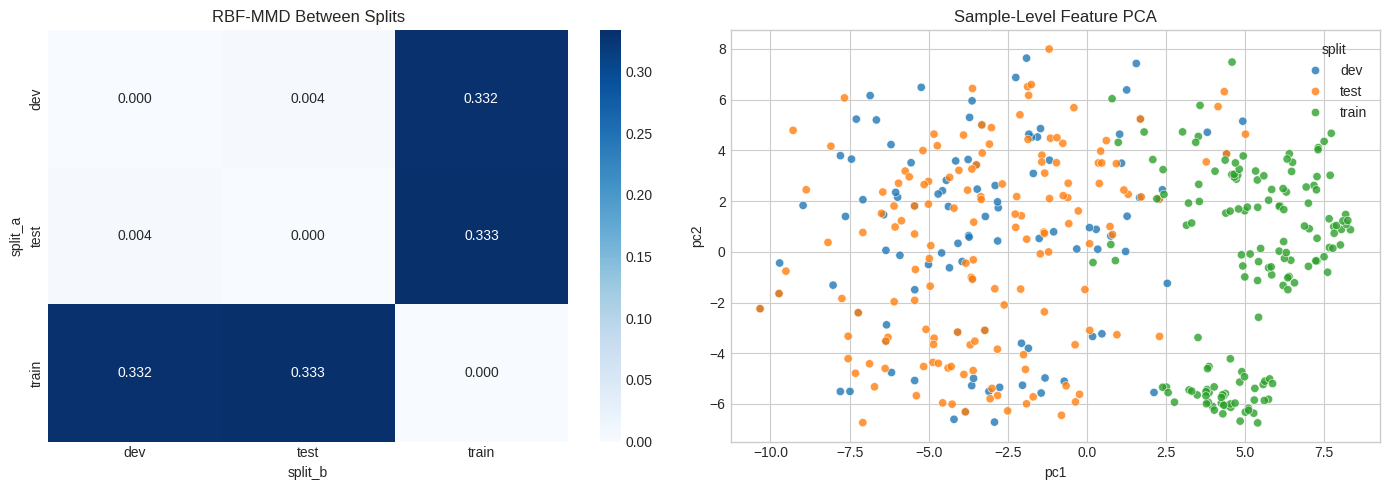

In [19]:
# Plot: MMD heatmap과 PCA scatter로 split 간 분포 차이를 시각화하는 셀
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(mmd_matrix, annot=True, fmt='.3f', cmap='Blues', ax=axes[0])
axes[0].set_title('RBF-MMD Between Splits')

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(domain_X)
pca_df = pd.DataFrame({
    'pc1': coords[:, 0],
    'pc2': coords[:, 1],
    'split': sample_level_df['split'].to_numpy(),
})
sns.scatterplot(data=pca_df, x='pc1', y='pc2', hue='split', alpha=0.8, ax=axes[1])
axes[1].set_title('Sample-Level Feature PCA')

plt.tight_layout()


shadow_angle_deg                              shadow_angle_wrapped_deg                              shadow_area_ratio                        
                 count     mean    median       std                    count      mean    median      std             count    mean  median     std
split                                                                                                                                              
dev                 88  19.5379   87.7289  142.1919                       88  154.5379  169.4115  50.7443                88  0.0144  0.0101  0.0123
test               138  33.9391   93.3322  140.1883                      138  148.7217  166.4491  49.0906               138  0.0148  0.0105  0.0127
train              107  84.3588  132.8582  112.5814                      107  141.5551  145.7873  34.2124               107  0.0032  0.0021  0.0039

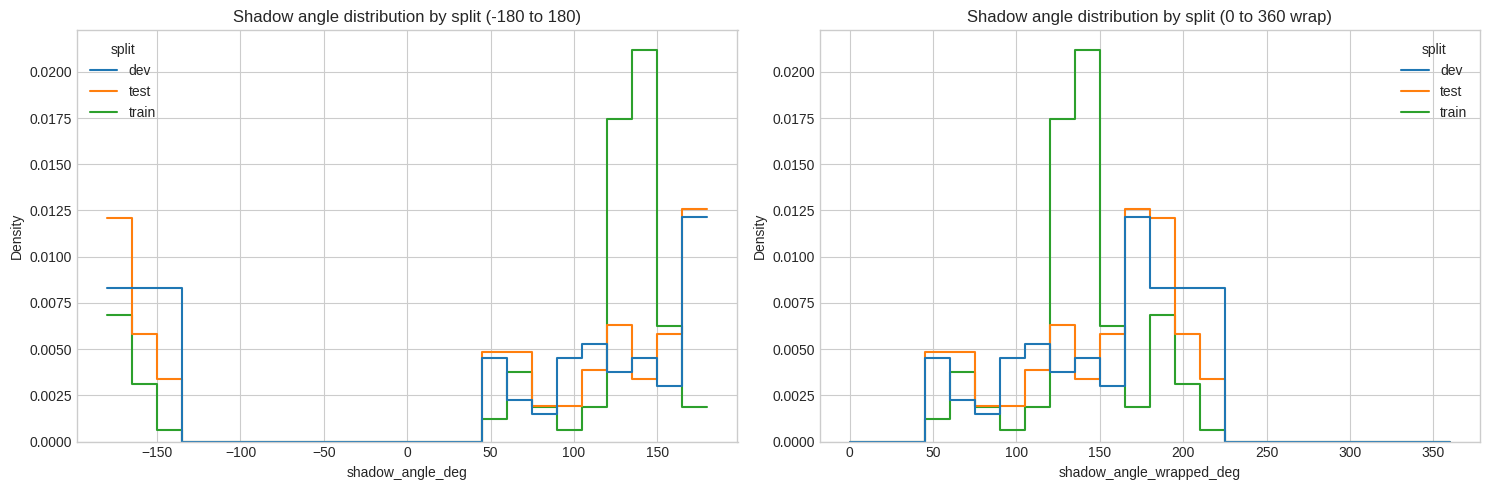

In [20]:
# Shadow angle distribution: split별 그림자 각도 분포를 히스토그램으로 보는 셀
shadow_angle_df = front_geom[['split', 'sample_id', 'shadow_angle_deg', 'shadow_area_ratio']].copy()
shadow_angle_df = shadow_angle_df.dropna(subset=['shadow_angle_deg']).copy()
shadow_angle_df = shadow_angle_df[shadow_angle_df['shadow_area_ratio'].fillna(0) > 0].copy()
shadow_angle_df['shadow_angle_wrapped_deg'] = (shadow_angle_df['shadow_angle_deg'] + 360) % 360

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bins_raw = np.arange(-180, 181, 15)
bins_wrapped = np.arange(0, 361, 15)

sns.histplot(
    data=shadow_angle_df,
    x='shadow_angle_deg',
    hue='split',
    bins=bins_raw,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
    ax=axes[0],
)
axes[0].set_title('Shadow angle distribution by split (-180 to 180)')
axes[0].set_xlabel('shadow_angle_deg')

sns.histplot(
    data=shadow_angle_df,
    x='shadow_angle_wrapped_deg',
    hue='split',
    bins=bins_wrapped,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
    ax=axes[1],
)
axes[1].set_title('Shadow angle distribution by split (0 to 360 wrap)')
axes[1].set_xlabel('shadow_angle_wrapped_deg')

plt.tight_layout()

display(
    shadow_angle_df.groupby('split')[['shadow_angle_deg', 'shadow_angle_wrapped_deg', 'shadow_area_ratio']]
    .agg(['count', 'mean', 'median', 'std'])
    .round(4)
)


## Reading notes

추천 해석 포인트
- `noise_residual_std`, `fft_high_freq_ratio`: 렌더러/후처리 차이, compression 차이, aliasing 차이를 보기 좋습니다.
- `brightness_mean`, `saturation_mean`, HSV histogram: split별 조명/화이트밸런스 차이를 보기 좋습니다.
- `vp_pitch_proxy`, `vp_spread`: front 카메라의 시선 높이/피치 변화와 투시 일관성을 보는 proxy입니다.
- `distortion_proxy`: 광학 왜곡 그 자체보다, 체커 선이 얼마나 곧게 유지되는지 보는 plumb-line 스타일 근사치입니다.
- `shadow_angle_deg`, `shadow_area_ratio`: 광원 방향과 구조물 높이감 차이를 반영할 수 있습니다.
- `structure_bbox_h`, `structure_area_ratio`: crop/FOV/촬영거리 차이를 보는 데 유용합니다.
- domain classifier importance: 어떤 handcrafted feature가 split 구분에 가장 크게 기여하는지 보여줍니다.
- MMD heatmap: 분류기와 별개로 split 간 분포 차이를 직접 수치화합니다.

추가로 해볼 만한 분석
- `front`와 `top`을 연결한 multiview consistency: 구조물 centroid / footprint 정렬 정도
- 영상(`simulation.mp4`)이 있는 `train/generated_v2`에서 optical flow 기반 흔들림 prior 추출
- 중요 feature만 골라 augmentation/normalization 정책으로 연결
